Problem 1.

$$
U(x,y) = \frac{\epsilon}{2} \left(\left|\frac{x}{a}\right| + \left|\frac{y}{b}\right| \right)
$$

Relevant notes: Lecture 8

a) Homogeneity $k = 1$

$$
U(\alpha x, \alpha y) = \alpha U(x,y)
$$

<!-- So Euler's theorem says 
$$
U(x,y) = \frac{\partial U(x,y)}{\partial x} + \frac{\partial U(x,y)}{\partial y}
$$ -->

b) The total energy is $T+U = \mathcal{E}$, so we can use our degree of homogeneity $k=1$
$$
\\  \langle T \rangle + \langle U \rangle = \mathcal{E}
\\ 2\langle T \rangle = \langle U \rangle
\\  \langle T \rangle = \frac{1 \mathcal E}{3}
\\  \langle U \rangle = \frac{2\mathcal E}{3}
$$



c) Ripping directly from Bunker's notebook:

| k | orbitsize    | period   | velocity | angularmomentum | energy | action |
| --| ---          | ---      | ---      | ---             | ---    | ---    |
| k = 1 | $\alpha$ |$\sqrt{\alpha}$|$\sqrt{\alpha}$          |$\alpha^{3/2}$                 |$\alpha$        |$\alpha^{3/2} $       |

Using $\phi = \alpha$

Problem 2.

Mechanics of the previous problem.

a)
$$
L = T - U = \frac{1}{2} m \left(v_x^2 + v_y^2 \right) - \frac{\epsilon}{2} \left(\left|\frac{x}{a}\right| + \left|\frac{y}{b}\right| \right)
$$

b)
$$
    L(x, \dot x,y, \dot y) = L_x(x, \dot x) + L_y(y, \dot y)
\\  L_x(x, \dot x) = \frac{1}{2} m \dot x^2 - \frac{\epsilon}{2a} |x|
\\  L_y(y, \dot y) = \frac{1}{2} m \dot y^2 - \frac{\epsilon}{2b} |y|
$$

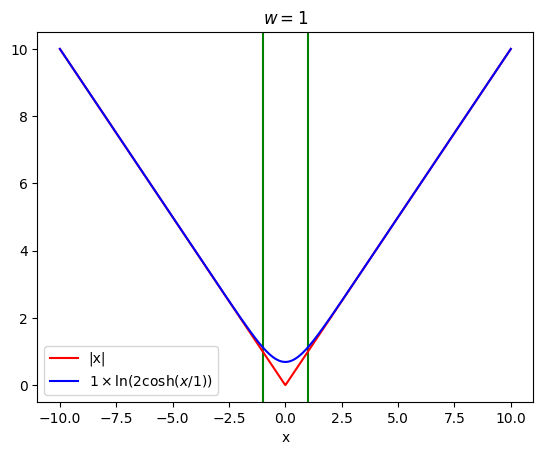

In [13]:
# c)

import matplotlib.pyplot as plt
import numpy as np

w = 1
x = np.linspace(-10*w,10*w, 1000)
plt.axvline(-w, color='green')
plt.axvline( w, color='green')
plt.plot(x, np.abs(x), color = 'red', label='|x|')
plt.plot(x, w*np.log(2*np.cosh(x/w)), color = 'blue', label=rf'${w}\times\ln(2\cosh(x/{w}))$')
plt.xlabel('x')
plt.legend()
plt.title(rf'$w={w}$');

In [ ]:
# d) The EOMs are
import sympy as sp
from sympy.physics.mechanics import *
w, m, a, b, epsilon, t= sp.symbols('w m a b epsilon t', positive='True')
x, y = dynamicsymbols('x y')
dx, dy = dynamicsymbols('x y', 1)
ddy = dynamicsymbols('y', 2)

def analytic_abs(x, w):
    return w * sp.ln(2*sp.cosh(x/w))

T = 1/2 * m * (dx*dx + dy*dy)
U = epsilon / 2 * ( analytic_abs(x, w)/a + analytic_abs(y, w)/b )
L = T - U
display(sp.simplify(L))

LM = LagrangesMethod(L, [x, y])
for lhs in LM.form_lagranges_equations():
    EOM = sp.Eq(lhs, 0)
    display(sp.simplify(EOM))

(1.0*a*b*m*(Derivative(x(t), t)**2 + Derivative(y(t), t)**2) - epsilon*w*(a*log(2*cosh(y(t)/w)) + b*log(2*cosh(x(t)/w))))/(2*a*b)

Eq(1.0*m*Derivative(x(t), (t, 2)) + 0.5*epsilon*tanh(x(t)/w)/a, 0)

Eq(1.0*m*Derivative(y(t), (t, 2)) + 0.5*epsilon*tanh(y(t)/w)/b, 0)

Problem 3.

$$
U(x) = \frac{\epsilon}{2} \left(\left(\frac{x}{a}\right)^2 + \left(\frac{a}{x} \right)^2 \right)
$$

i) Turning points will depend on total energy.

$$
\mathcal{E} = U(x)
$$

In [72]:
a, epsilon, E = sp.symbols('a epsilon E', positive=True)
x = sp.symbols('x')

U = epsilon/2 * ((x/a)**2 + (a/x)**2)
display(*sp.solve(sp.Eq(U, E), x))

-a*sqrt(E - sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

a*sqrt(E - sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

-a*sqrt(E + sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

a*sqrt(E + sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

That's double the number of solutions we want? Actually, this result makes sense since the potential is mirrored across the y-axis. 

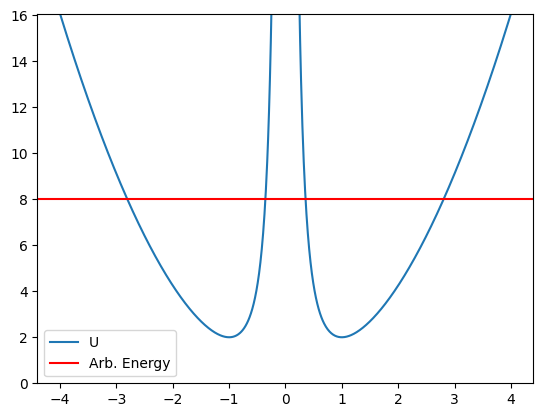

In [87]:
a = 1
x = np.linspace(-4*a, 4*a, 1000)
U = (x/a)**2+(a/x)**2
U[U > 1000] = 1000

plt.plot(x, U, label='U');
plt.ylim(0, U[-1])
plt.axhline(8, label='Arb. Energy', color='red')
plt.legend();